1 : Importation des outils

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Outils de Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
# Métriques d'évaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


2 : Chargement et préparation finale

In [4]:
# Chargement des données
df_enron = pd.read_csv('../data/enron_preprocessed.csv')

# Sécurité : on s'assure qu'il n'y a pas de valeurs nulles apparues après le nettoyage
df_enron['text_preprocessed'] = df_enron['text_preprocessed'].fillna('')

print(f"Taille du dataset : {df_enron.shape}")

Taille du dataset : (33716, 2)


3 : TF-IDF et séparation Train/Test

In [5]:
# 1. Initialisation du TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)

# 2. Transformation du texte 
X_enron = vectorizer.fit_transform(df_enron['text_preprocessed'])
y_enron = df_enron['Spam/Ham']

# 3. Division en données d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_enron, y_enron, test_size=0.2, random_state=42)

print(f"Dimensions de X_train : {X_train.shape}")
print(f"Dimensions de X_test : {X_test.shape}")

Dimensions de X_train : (26972, 5000)
Dimensions de X_test : (6744, 5000)


4 : Entraînement et Évaluation - Naive Bayes

--- RÉSULTATS : NAIVE BAYES ---
Accuracy  : 0.9865
Precision : 0.9744
Recall    : 1.0000
F1-Score  : 0.9870


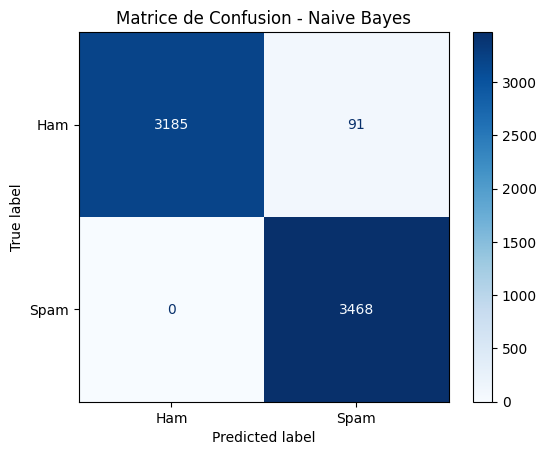

In [6]:
print("--- RÉSULTATS : NAIVE BAYES ---")
# Initialisation et entraînement
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Prédictions sur les données de test
y_pred_nb = nb_model.predict(X_test)

# Calcul des métriques
print(f"Accuracy  : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_nb):.4f}")

# Affichage de la matrice de confusion
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Ham', 'Spam'])
disp_nb.plot(cmap='Blues')
plt.title("Matrice de Confusion - Naive Bayes")
plt.savefig('../resultats/03_confusion_matrix_nb.png', bbox_inches='tight', dpi=300)
plt.show()

5 : Entraînement et Évaluation - Random Forest

--- RÉSULTATS : RANDOM FOREST ---
Accuracy  : 0.9996
Precision : 0.9991
Recall    : 1.0000
F1-Score  : 0.9996


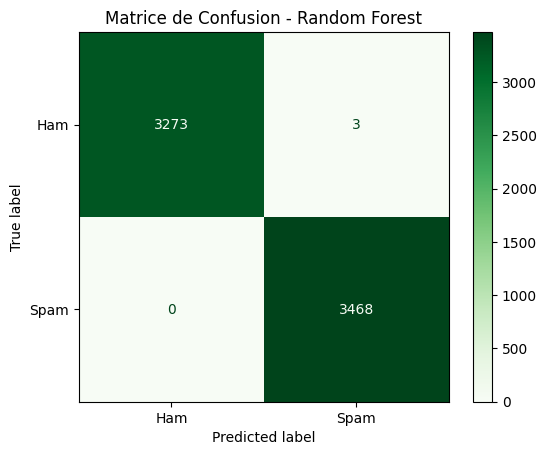

In [7]:
print("--- RÉSULTATS : RANDOM FOREST ---")
# Initialisation et entraînement (n_estimators = nombre d'arbres)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Prédictions sur les données de test
y_pred_rf = rf_model.predict(X_test)

# Calcul des métriques
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_rf):.4f}")

# Affichage de la matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Ham', 'Spam'])
disp_rf.plot(cmap='Greens')
plt.title("Matrice de Confusion - Random Forest")
plt.savefig('../resultats/04_confusion_matrix_rf.png', bbox_inches='tight', dpi=300)
plt.show()

In [8]:
# --- TABLEAU COMPARATIF DES RÉSULTATS ---

resultats = {
    'Métriques': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Naive Bayes': [
        accuracy_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_nb)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ]
}

# Création du DataFrame
df_comparatif = pd.DataFrame(resultats)

# Affichage du tableau
print("Comparaison des Modèles :")
display(df_comparatif)

# Optionnel : Sauvegarder le tableau en CSV dans le dossier résultats
df_comparatif.to_csv('../resultats/comparaison_modeles.csv', index=False)

Comparaison des Modèles :


,Métriques,Naive Bayes,Random Forest
0,Accuracy,0.986507,0.999555
1,Precision,0.974431,0.999136
2,Recall,1.000000,1.000000
3,F1-Score,0.987050,0.999568


Vérification de surapprentissage 

Méthode 1 : Comparaison des scores Train vs Test

In [9]:
# --- MÉTHODE 1 : COMPARAISON TRAIN VS TEST ---

# Prédictions sur les données d'entraînement
y_train_pred_nb = nb_model.predict(X_train)
y_train_pred_rf = rf_model.predict(X_train)

# Calcul de l'Accuracy sur le Train
acc_train_nb = accuracy_score(y_train, y_train_pred_nb)
acc_train_rf = accuracy_score(y_train, y_train_pred_rf)

# Récupération de l'Accuracy sur le Test (déjà calculée précédemment)
acc_test_nb = accuracy_score(y_test, y_pred_nb)
acc_test_rf = accuracy_score(y_test, y_pred_rf)

# Création d'un tableau récapitulatif
data_overfitting = {
    'Modèle': ['Naive Bayes', 'Random Forest'],
    'Score Entraînement (Train)': [acc_train_nb, acc_train_rf],
    'Score Test': [acc_test_nb, acc_test_rf],
    'Différence (Train - Test)': [acc_train_nb - acc_test_nb, acc_train_rf - acc_test_rf]
}

df_overfitting = pd.DataFrame(data_overfitting)
print("Analyse du Surapprentissage (Train vs Test) :")
display(df_overfitting)
# Optionnel : Sauvegarder le tableau en CSV dans le dossier résultats
df_comparatif.to_csv('../resultats/comparaison_modeles.csv', index=False)

Analyse du Surapprentissage (Train vs Test) :


,Modèle,Score Entraînement (Train),Score Test,Différence (Train - Test)
0,Naive Bayes,0.987691,0.986507,0.001184
1,Random Forest,0.999852,0.999555,0.000297


Méthode 2 : La Validation Croisée (Cross-Validation)

In [10]:
from sklearn.model_selection import cross_val_score

# --- MÉTHODE 2 : VALIDATION CROISÉE (5 FOLDS) ---
print("Lancement de la validation croisée ")

# Validation croisée pour Naive Bayes
cv_scores_nb = cross_val_score(nb_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"--- NAIVE BAYES ---")
print(f"Scores des 5 tests : {cv_scores_nb}")
print(f"Moyenne CV         : {cv_scores_nb.mean():.4f} (+/- {cv_scores_nb.std() * 2:.4f})\n")

# Validation croisée pour Random Forest
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f"--- RANDOM FOREST ---")
print(f"Scores des 5 tests : {cv_scores_rf}")
print(f"Moyenne CV         : {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")

Lancement de la validation croisée 
--- NAIVE BAYES ---
Scores des 5 tests : [0.98776645 0.98776645 0.98683723 0.98665184 0.98887653]
Moyenne CV         : 0.9876 (+/- 0.0016)

--- RANDOM FOREST ---
Scores des 5 tests : [0.99981464 1.         0.99962922 0.99981461 1.        ]
Moyenne CV         : 0.9999 (+/- 0.0003)


Hyperparameter Tuning

In [11]:


print("Démarrage de l'optimisation des modèles..\n")

# --- 1. OPTIMISATION DE NAIVE BAYES ---
# L'hyperparamètre principal est 'alpha' (le lissage)
param_grid_nb = {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}

# cv=5 (Validation croisée), n_jobs=-1 (utilise tous les processeurs de ton PC)
grid_nb = GridSearchCV(MultinomialNB(), param_grid_nb, cv=5, scoring='accuracy', n_jobs=-1)
grid_nb.fit(X_train, y_train)

best_nb = grid_nb.best_estimator_
print(f"Meilleurs paramètres Naive Bayes : {grid_nb.best_params_}")


# --- 2. OPTIMISATION DE RANDOM FOREST ---
# On teste le nombre d'arbres (n_estimators) et la profondeur maximale (max_depth)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 50]
}

# cv=3 pour aller un peu plus vite avec le Random Forest
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print(f"Meilleurs paramètres Random Forest : {grid_rf.best_params_}\n")
print("✅ Optimisation terminée !")

Démarrage de l'optimisation des modèles..

Meilleurs paramètres Naive Bayes : {'alpha': 0.01}
Meilleurs paramètres Random Forest : {'max_depth': None, 'n_estimators': 100}

✅ Optimisation terminée !


Comparaison Finale des Modèles Optimisés

In [12]:
# --- COMPARAISON FINALE SUR LES DONNÉES DE TEST ---

# Prédictions avec les modèles optimisés
y_pred_best_nb = best_nb.predict(X_test)
y_pred_best_rf = best_rf.predict(X_test)

# Création d'un tableau récapitulatif
resultats_finaux = {
    'Métriques': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Naive Bayes Optimisé': [
        accuracy_score(y_test, y_pred_best_nb),
        precision_score(y_test, y_pred_best_nb),
        recall_score(y_test, y_pred_best_nb),
        f1_score(y_test, y_pred_best_nb)
    ],
    'Random Forest Optimisé': [
        accuracy_score(y_test, y_pred_best_rf),
        precision_score(y_test, y_pred_best_rf),
        recall_score(y_test, y_pred_best_rf),
        f1_score(y_test, y_pred_best_rf)
    ]
}

df_comparatif_final = pd.DataFrame(resultats_finaux)
print("Comparaison Finale des Modèles Optimisés :")
display(df_comparatif_final)
df_comparatif_final.to_csv('../resultats/comparaison_modeles_final.csv', index=False)

Comparaison Finale des Modèles Optimisés :


,Métriques,Naive Bayes Optimisé,Random Forest Optimisé
0,Accuracy,0.990362,0.999555
1,Precision,0.981602,0.999136
2,Recall,1.000000,1.000000
3,F1-Score,0.990716,0.999568


La décision est de choisir randomForest comme un modéle

In [13]:




# Sauvegarder le TF-IDF
joblib.dump(vectorizer, '../modeles/tfidf_vectorizer.pkl')

# Sauvegarder le modèle random forest
joblib.dump(best_rf, '../modeles/modele_spam_choisi.pkl')

print("✅ Le modèle optimisé et le Vectorizer ont été sauvegardés !")

✅ Le modèle optimisé et le Vectorizer ont été sauvegardés !
